In [1]:
# Import the FEMSystem Class from directory above
import sys
sys.path.append('../..')
from FEMSystem import FEMSystem

import jax.numpy as jnp
import pickle
import matplotlib.pyplot as plt
import numpy as np
from jax.scipy.sparse.linalg import cg

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"


'''
Fill in File Path
'''
file_path1 = '../allplots/sepsweep3/sep1/results.pkl'
file_path2 = '../allplots/sepsweep3/sep15/results.pkl'

########################################################

pickled_obj = {}
with open(file_path1, 'rb') as f:
    pickled_obj1 = pickle.load(f)
    femsystem1:FEMSystem = pickled_obj1["femsystem"]
    femsystem1.saveFigsDir = None # Turn OFF saving plots
    u_even1,u_odd1 = pickled_obj1["u_even"],pickled_obj1["u_odd"]

    # Normalize the modes
    u_even1 = u_even1 / femsystem1.integrate(lambda u,a,b: u**2,u_even1)
    u_odd1 = u_odd1 / femsystem1.integrate(lambda u,a,b: u**2,u_odd1)

    u_even_interior1,u_odd_interior1 = u_even1[femsystem1.interior_dofs],u_odd1[femsystem1.interior_dofs]
    u_left_interior1,u_right_interior1 = (u_even_interior1+u_odd_interior1)/jnp.sqrt(2), (u_even_interior1-u_odd_interior1)/jnp.sqrt(2)

    n1,coeffs1 = pickled_obj1["n"],pickled_obj1["coeffs"]
    x1 = (n1-1)/2 - jnp.arange(n1)
with open(file_path2, 'rb') as f:
    pickled_obj2 = pickle.load(f)
    femsystem2:FEMSystem = pickled_obj2["femsystem"]
    femsystem2.saveFigsDir = None # Turn OFF saving plots
    u_even2,u_odd2 = pickled_obj2["u_even"],pickled_obj2["u_odd"]

    # Normalize the modes
    u_even2 = u_even2 / femsystem2.integrate(lambda u,a,b: u**2,u_even2)
    u_odd2 = u_odd2 / femsystem2.integrate(lambda u,a,b: u**2,u_odd2)

    u_even_interior2,u_odd_interior2 = u_even2[femsystem2.interior_dofs],u_odd2[femsystem2.interior_dofs]
    u_left_interior2,u_right_interior2 = (u_even_interior2+u_odd_interior2)/jnp.sqrt(2), (u_even_interior2-u_odd_interior2)/jnp.sqrt(2) 

    n2,coeffs2 = pickled_obj2["n"],pickled_obj2["coeffs"]
    x2 = (n2-1)/2 - jnp.arange(n2)

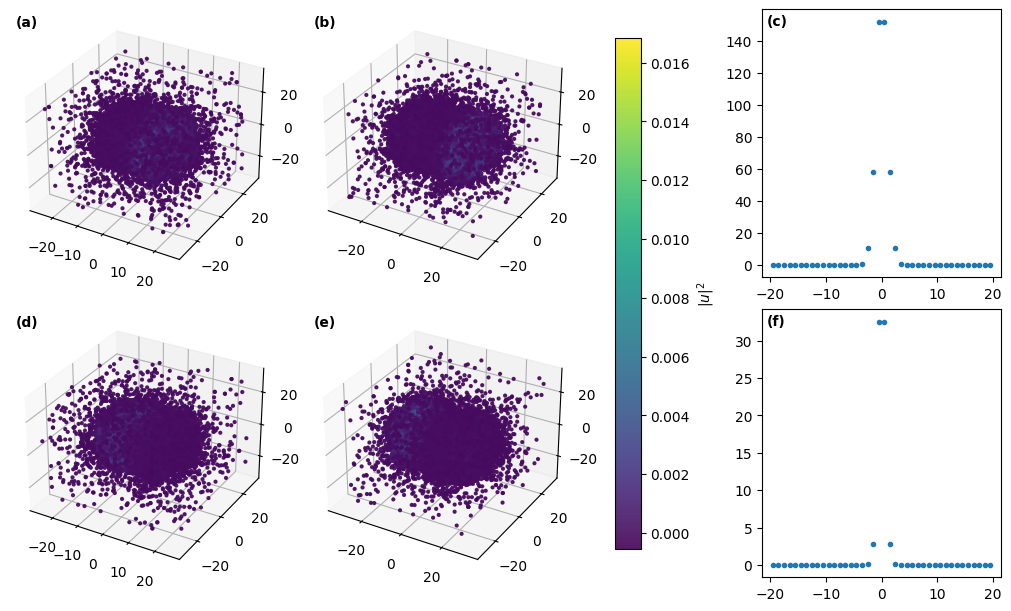

In [6]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

def get_quad_cloud(femsystem, u_interior, value_threshold=None, max_points=50000):
    u_global = femsystem._get_u_from_interior(u_interior)
    u_quad = femsystem._interpolate_values(u_global)
    coords = np.asarray(femsystem.coords_q_T).reshape(3, -1)
    vals = np.asarray(u_quad).ravel()

    if value_threshold is not None:
        m = np.abs(vals) > value_threshold
        coords, vals = coords[:, m], vals[m]

    if coords.shape[1] > max_points:
        idx = np.random.choice(coords.shape[1], max_points, replace=False)
        coords, vals = coords[:, idx], vals[idx]

    return coords, vals

# 1) Build datasets from 4 different FEMSystems
datasets = [
    get_quad_cloud(femsystem1, u_left_interior1),
    get_quad_cloud(femsystem2, u_left_interior2),
    get_quad_cloud(femsystem1, u_right_interior1),
    get_quad_cloud(femsystem2, u_right_interior2),
]

# 2) Global normalization across all 4
all_vals = np.concatenate([v for _, v in datasets])
vmin, vmax = np.percentile(all_vals, [1, 99])   # robust; or min/max
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = "viridis"

fig = plt.figure(figsize=(10, 6), constrained_layout=True)
gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.9])

ax_a = fig.add_subplot(gs[0, 0], projection="3d")
ax_b = fig.add_subplot(gs[0, 1], projection="3d")
ax_d = fig.add_subplot(gs[1, 0], projection="3d")
ax_e = fig.add_subplot(gs[1, 1], projection="3d")
ax_c = fig.add_subplot(gs[0, 2])   # coeff plot 1
ax_f = fig.add_subplot(gs[1, 2])   # coeff plot 2

heat_axes = [ax_a, ax_b, ax_d, ax_e]
mappable_ref = None
for ax, (coords, vals) in zip(heat_axes, datasets):
    sc = ax.scatter(coords[0], coords[1], coords[2], c=vals, s=4, cmap=cmap, norm=norm, alpha=0.9)
    if mappable_ref is None:
        mappable_ref = sc
    # optional: same view/limits
    # ax.view_init(elev=25, azim=-60)

# single shared colorbar for heatmaps only
cbar = fig.colorbar(mappable_ref, ax=heat_axes, location="right", shrink=0.9, pad=0.03)
cbar.set_label(r"$|u|^2$")  # or your quantity

# coefficient panels
ax_c.plot(x1, coeffs1, ".")
ax_f.plot(x2, coeffs2, ".")

# labels: top-left
for ax, lab in zip([ax_a, ax_b, ax_c, ax_d, ax_e, ax_f], ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]):
    if hasattr(ax, "text2D"):  # 3D axes
        ax.text2D(0.02, 0.98, lab, transform=ax.transAxes, ha="left", va="top", fontweight="bold")
    else:
        ax.text(0.02, 0.98, lab, transform=ax.transAxes, ha="left", va="top", fontweight="bold")

fig.savefig("paper_fig_modes_coeffs.pdf", bbox_inches="tight")

ValueError: The number of colors must match the number of alpha values if there are more than one of each.

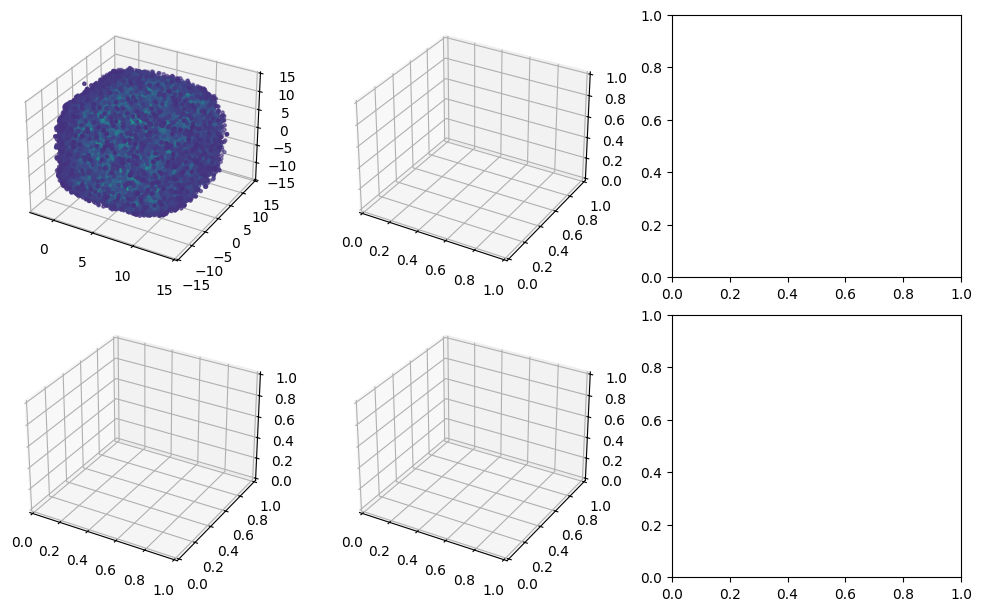

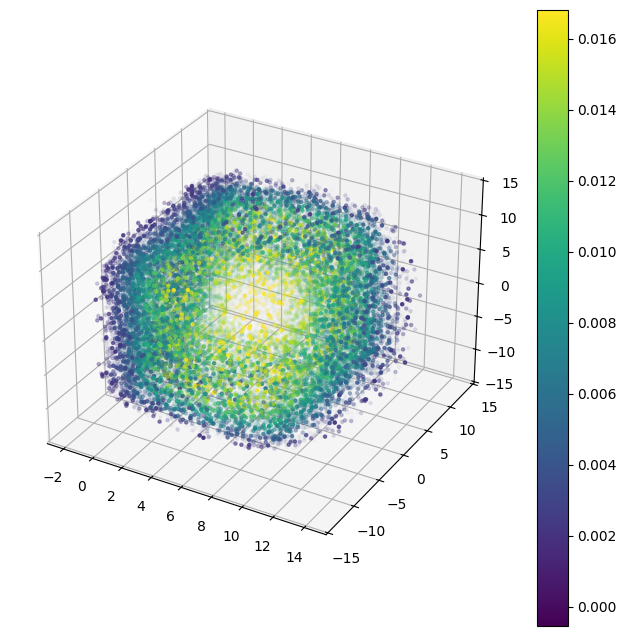

In [4]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np


def get_quad_cloud(femsystem, u_interior, value_threshold=None, max_points=50000):
    """Only used to compute one shared vmin/vmax across all 4 heatmaps."""
    u_global = femsystem._get_u_from_interior(u_interior)
    u_quad = femsystem._interpolate_values(u_global)
    coords = np.asarray(femsystem.coords_q_T).reshape(3, -1)
    vals = np.asarray(u_quad).ravel()

    if value_threshold is not None:
        m = np.abs(vals) > value_threshold
        coords, vals = coords[:, m], vals[m]

    if coords.shape[1] > max_points:
        idx = np.random.choice(coords.shape[1], max_points, replace=False)
        coords, vals = coords[:, idx], vals[idx]

    return coords, vals


def draw_heatmap_like_original(ax_target, femsystem, u_interior, vmin, vmax):
    """
    Call FEMSystem.plot_interior_at_quad_3d_heatmap (your original style),
    then copy that scatter to ax_target in the 2x3 figure.
    """
    fig_tmp, ax_tmp, sc_tmp = femsystem.plot_interior_at_quad_3d_heatmap(
        u_interior,
        plot_title="",
        vmin=vmin,
        vmax=vmax,
    )

    x, y, z = sc_tmp._offsets3d
    vals = np.asarray(sc_tmp.get_array())

    sc = ax_target.scatter(
        x, y, z,
        c=vals,
        s=sc_tmp.get_sizes(),
        cmap=sc_tmp.cmap,
        norm=sc_tmp.norm,
        depthshade=True,
    )

    # Keep per-point alpha/colors from the original method.
    facecolors = sc_tmp.get_facecolors()
    if facecolors is not None and len(facecolors) == len(vals):
        sc.set_facecolors(facecolors)
        sc.set_edgecolors(facecolors)

    # Copy camera and limits so it looks the same as standalone plots.
    ax_target.view_init(elev=ax_tmp.elev, azim=ax_tmp.azim)
    ax_target.set_xlim(ax_tmp.get_xlim3d())
    ax_target.set_ylim(ax_tmp.get_ylim3d())
    ax_target.set_zlim(ax_tmp.get_zlim3d())
    ax_target.set_xlabel(ax_tmp.get_xlabel())
    ax_target.set_ylabel(ax_tmp.get_ylabel())
    ax_target.set_zlabel(ax_tmp.get_zlabel())

    plt.close(fig_tmp)
    return sc


# Compute one shared normalization range (same color-to-value mapping everywhere).
datasets = [
    get_quad_cloud(femsystem1, u_left_interior1),
    get_quad_cloud(femsystem2, u_left_interior2),
    get_quad_cloud(femsystem1, u_right_interior1),
    get_quad_cloud(femsystem2, u_right_interior2),
]
all_vals = np.concatenate([v for _, v in datasets])
vmin, vmax = np.percentile(all_vals, [1, 99])
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# Build 2x3 layout.
fig = plt.figure(figsize=(10, 6), constrained_layout=True)
gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.9])

ax_a = fig.add_subplot(gs[0, 0], projection="3d")
ax_b = fig.add_subplot(gs[0, 1], projection="3d")
ax_d = fig.add_subplot(gs[1, 0], projection="3d")
ax_e = fig.add_subplot(gs[1, 1], projection="3d")
ax_c = fig.add_subplot(gs[0, 2])
ax_f = fig.add_subplot(gs[1, 2])

heat_axes = [ax_a, ax_b, ax_d, ax_e]
heat_data = [
    (femsystem1, u_left_interior1),
    (femsystem2, u_left_interior2),
    (femsystem1, u_right_interior1),
    (femsystem2, u_right_interior2),
]

mappable_ref = None
for ax, (femsystem, u_interior) in zip(heat_axes, heat_data):
    sc = draw_heatmap_like_original(ax, femsystem, u_interior, vmin=vmin, vmax=vmax)
    if mappable_ref is None:
        mappable_ref = plt.cm.ScalarMappable(norm=norm, cmap=sc.cmap)

# One shared colorbar for all 4 heatmaps.
cbar = fig.colorbar(mappable_ref, ax=heat_axes, location="right", shrink=0.9, pad=0.03)
cbar.set_label(r"$|u|^2$")

# Coefficient panels.
ax_c.plot(x1, coeffs1, ".")
ax_f.plot(x2, coeffs2, ".")

# Panel labels (a)-(f), top-left.
for ax, lab in zip([ax_a, ax_b, ax_c, ax_d, ax_e, ax_f], ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]):
    if hasattr(ax, "text2D"):  # 3D axes
        ax.text2D(0.02, 0.98, lab, transform=ax.transAxes, ha="left", va="top", fontweight="bold")
    else:
        ax.text(0.02, 0.98, lab, transform=ax.transAxes, ha="left", va="top", fontweight="bold")

fig.savefig("paper_fig_modes_coeffs.pdf", bbox_inches="tight")
plt.show()

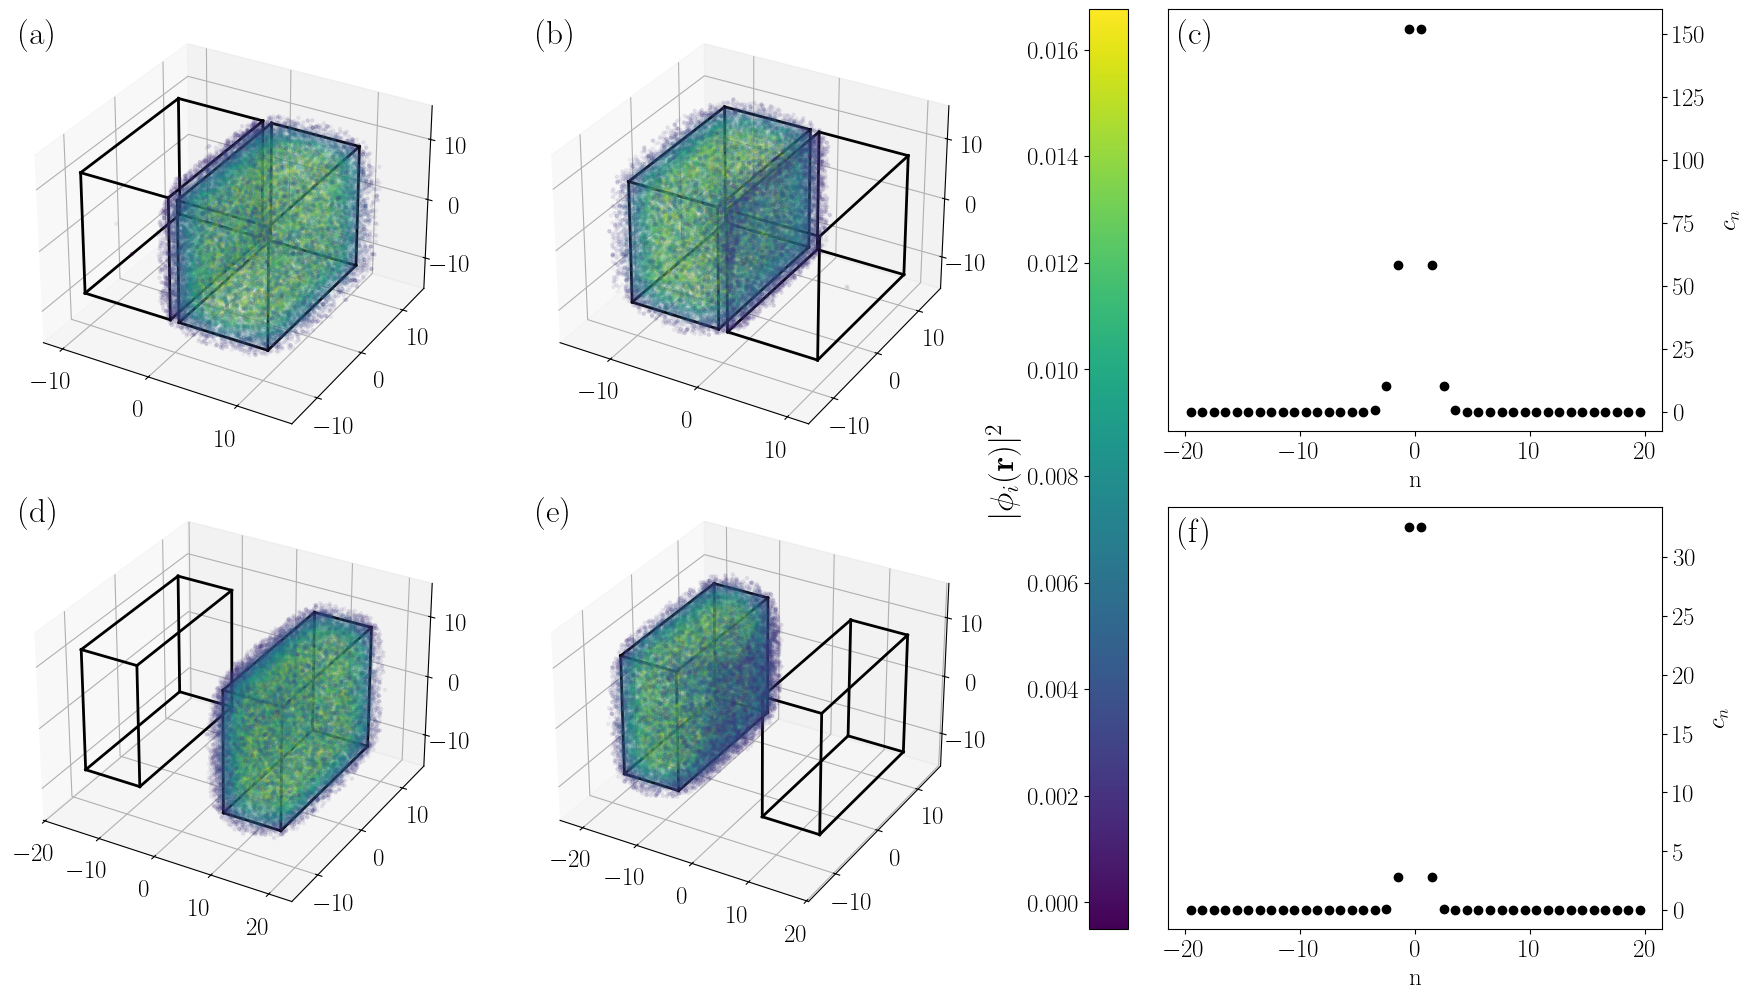

In [43]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 18,
})

# Collect all values once to set one shared color mapping across all 4 heatmaps.
def quad_vals(femsystem, u_interior):
    u_global = femsystem._get_u_from_interior(u_interior)
    u_quad = femsystem._interpolate_values(u_global)
    return np.asarray(u_quad).ravel()

all_vals = np.concatenate([
    quad_vals(femsystem1, u_left_interior1),
    quad_vals(femsystem2, u_left_interior2),
    quad_vals(femsystem1, u_right_interior1),
    quad_vals(femsystem2, u_right_interior2),
])

# Keep robust range; switch to (all_vals.min(), all_vals.max()) if you prefer strict min/max.
vmin, vmax = np.percentile(all_vals, [1, 99])

fig = plt.figure(figsize=(18, 10), constrained_layout=False)

# Robust non-overlapping layout:
# - Left block: 2x2 heatmaps with zero internal horizontal gap.
# - Right block: thin colorbar column + coefficient column with explicit spacing.
outer = fig.add_gridspec(1, 2, width_ratios=[2.0, 1.0], wspace=0.03)
# Slight negative wspace pulls the two left heatmap columns closer.
left = outer[0, 0].subgridspec(2, 2, wspace=-0.18, hspace=0.08)
# More vertical spacing on right block prevents label/title collisions.
right = outer[0, 1].subgridspec(2, 2, width_ratios=[0.08, 1.0], wspace=0.15, hspace=0.18)

ax_a = fig.add_subplot(left[0, 0], projection="3d")
ax_b = fig.add_subplot(left[0, 1], projection="3d")
ax_d = fig.add_subplot(left[1, 0], projection="3d")
ax_e = fig.add_subplot(left[1, 1], projection="3d")
cax = fig.add_subplot(right[:, 0])
ax_c = fig.add_subplot(right[0, 1])
ax_f = fig.add_subplot(right[1, 1])

# Match styling from single.ipynb so the 4 heatmaps look the same.
threshold = 0.0017
max_points = 40000
wire_color = "black"
wire_linewidth = 2.0
opacity_power = 1.5
alpha_lo = 0.10
alpha_hi = 0.01

# Use matplotlib's default 3D depth ordering (better perspective occlusion).

def prism_args_from_pickled(pickled_obj):
    params = pickled_obj["parameters"]
    sidelenX = params["sidelenX"]
    sidelenY = params["sidelenY"]
    sidelenZ = params["sidelenZ"]
    separation = params["separation"]

    center_left = ((sidelenX + separation) / 2, 0, 0)
    center_right = (-(sidelenX + separation) / 2, 0, 0)
    prism_centers = [center_left, center_right]
    prism_side_lengths = [(sidelenX, sidelenY, sidelenZ), (sidelenX, sidelenY, sidelenZ)]
    return prism_centers, prism_side_lengths

prism_centers_1, prism_side_lengths_1 = prism_args_from_pickled(pickled_obj1)
prism_centers_2, prism_side_lengths_2 = prism_args_from_pickled(pickled_obj2)

# Directly call your original function, now drawing onto target axes.
_, _, sc_a = femsystem1.plot_interior_at_quad_3d_heatmap(
    u_left_interior1,
    plot_title="",
    vmin=vmin,
    vmax=vmax,
    max_points=max_points,
    value_threshold=threshold,
    alpha_lo=alpha_lo,
    alpha_hi=alpha_hi,
    prism_centers=prism_centers_1,
    prism_side_lengths=prism_side_lengths_1,
    wire_color=wire_color,
    wire_linewidth=wire_linewidth,
    opacity_power=opacity_power,
    ax=ax_a,
    add_colorbar=False,
)
_, _, _ = femsystem1.plot_interior_at_quad_3d_heatmap(
    u_right_interior1,
    plot_title="",
    vmin=vmin,
    vmax=vmax,
    max_points=max_points,
    value_threshold=threshold,
    alpha_lo=alpha_lo,
    alpha_hi=alpha_hi,
    prism_centers=prism_centers_1,
    prism_side_lengths=prism_side_lengths_1,
    wire_color=wire_color,
    wire_linewidth=wire_linewidth,
    opacity_power=opacity_power,
    ax=ax_b,
    add_colorbar=False,
)
_, _, _ = femsystem2.plot_interior_at_quad_3d_heatmap(
    u_left_interior2,
    plot_title="",
    vmin=vmin,
    vmax=vmax,
    max_points=max_points,
    value_threshold=threshold,
    alpha_lo=alpha_lo,
    alpha_hi=alpha_hi,
    prism_centers=prism_centers_2,
    prism_side_lengths=prism_side_lengths_2,
    wire_color=wire_color,
    wire_linewidth=wire_linewidth,
    opacity_power=opacity_power,
    ax=ax_d,
    add_colorbar=False,
)
_, _, _ = femsystem2.plot_interior_at_quad_3d_heatmap(
    u_right_interior2,
    plot_title="",
    vmin=vmin,
    vmax=vmax,
    max_points=max_points,
    value_threshold=threshold,
    alpha_lo=alpha_lo,
    alpha_hi=alpha_hi,
    prism_centers=prism_centers_2,
    prism_side_lengths=prism_side_lengths_2,
    wire_color=wire_color,
    wire_linewidth=wire_linewidth,
    opacity_power=opacity_power,
    ax=ax_e,
    add_colorbar=False,
)

# Shared colorbar in its own dedicated thin column.
mappable = plt.cm.ScalarMappable(norm=mcolors.Normalize(vmin=vmin, vmax=vmax), cmap=sc_a.cmap)
cbar = fig.colorbar(mappable, cax=cax)
# Put ticks/label on the left so nothing intrudes into coefficient panels.
cbar.ax.yaxis.set_ticks_position("left")
cbar.ax.yaxis.set_label_position("left")
cbar.set_label(r"$|\phi_i(\mathbf{r})|^2$", fontsize=24)

# Coefficient panels.
ax_c.plot(x1, coeffs1, ".", ms=12, color="black")
ax_c.set_title("")
ax_c.set_xlabel("n")
ax_c.set_ylabel("$c_n$", labelpad=8)
ax_c.yaxis.set_label_position("right")
ax_c.yaxis.tick_right()
ax_c.tick_params(axis="y", pad=4)

ax_f.plot(x2, coeffs2, ".", ms=12, color="black")
ax_f.set_title("")
ax_f.set_xlabel("n")
ax_f.set_ylabel("$c_n$", labelpad=8)
ax_f.yaxis.set_label_position("right")
ax_f.yaxis.tick_right()
ax_f.tick_params(axis="y", pad=4)
# Panel labels.
for ax, lab in zip([ax_a, ax_b, ax_c, ax_d, ax_e, ax_f], ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]):
    label_fontsize = 24
    if hasattr(ax, "text2D"):
        ax.text2D(
            0.02, 0.98, lab, 
            transform=ax.transAxes, 
            ha="left", va="top", fontsize=label_fontsize
        )
    else:
        ax.text(
            0.02, 0.98, lab, 
            transform=ax.transAxes, 
            ha="left", va="top", fontsize=label_fontsize
        )

fig.subplots_adjust(left=0.02, right=0.99, bottom=0.06, top=0.98)
fig.savefig("paper_fig_modes_coeffs.pdf", bbox_inches="tight")
plt.show()